In [2]:
import similaritymeasures
import numpy as np
from scipy.integrate import simpson
from scipy.spatial.distance import euclidean
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True  # Si tienes LaTeX instalado
mpl.rcParams['font.family'] = 'serif'

In [38]:
#--------------------------------- Estandarización
def estand(f):
    return (f-np.mean(f))/np.std(f)
#--------------------------------- DISTANCIAS L1 Y L2

def distancia_L2(f, g, x):
    return np.sqrt(simpson((f - g)**2, x))

def distancia_L1(f, g, x):
    return simpson(np.abs(f - g), x)

#----------------------------- CORRELACIÓN DE PEARSON FUNCIONAL

def pearson_funcional(f, g, x):
    f_mean = simpson(f, x) / (x[len(x)-1] - x[0])
    g_mean = simpson(g, x) / (x[len(x)-1] - x[0])
    numerator = simpson((f - f_mean) * (g - g_mean), x)
    denominator = np.sqrt(simpson((f - f_mean)**2, x) * simpson((g - g_mean)**2, x))
    return numerator / denominator

#----------------------------- Error Relativo Promedio
def ErrorRelativoPromedio(f,g,x):
    return np.abs(np.sum((f-g)/f)/len(x))

#---------------------------- Metrica
def ErrMetric(data):
    return distancia_L2(estand(data["SlowLight"]), estand(data["FastLight"]), estand(data["Time"]))

In [40]:
path_i17_s094 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ColorMap_data\LightCurve_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.94_i17_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path_i30_s094 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ColorMap_data\LightCurve_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.94_i30_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path_i60_s094 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ColorMap_data\LightCurve_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.94_i60_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path_i17_s05  = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ColorMap_data\LightCurve_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.5_i17_inoisy_n0.4_i0.5_ft5000_spatial512_snap8192.csv"
path_i30_s05  = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ColorMap_data\LightCurve_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.5_i30_inoisy_n0.4_i0.5_ft5000_spatial512_snap8192.csv"
path_i60_s05  = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ColorMap_data\LightCurve_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.5_i60_inoisy_n0.4_i0.5_ft5000_spatial512_snap8192.csv"



data_i17_s094 = pd.read_csv(path_i17_s094)
data_i30_s094 = pd.read_csv(path_i30_s094)
data_i60_s094 = pd.read_csv(path_i60_s094)
data_i17_s05  = pd.read_csv(path_i17_s05)
data_i30_s05  = pd.read_csv(path_i30_s05)
data_i60_s05  = pd.read_csv(path_i60_s05)

Err_i17_s094 = ErrMetric(data_i17_s094)
Err_i30_s094 = ErrMetric(data_i30_s094)
Err_i60_s094 = ErrMetric(data_i60_s094)
Err_i17_s05  = ErrMetric(data_i17_s05 )
Err_i30_s05  = ErrMetric(data_i30_s05 )
Err_i60_s05  = ErrMetric(data_i60_s05 )

In [42]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import re
datos = {
    'Err_i17_s094': Err_i17_s094, 
    'Err_i30_s094': Err_i30_s094, 
    'Err_i60_s094': Err_i60_s094, 
    'Err_i17_s05':  Err_i17_s05 , 
    'Err_i30_s05':  Err_i30_s05 , 
    'Err_i60_s05':  Err_i60_s05 , 
}

i_values = []
s_values = []
z_values = []

for nombre, valor in datos.items():
    match = re.search(r'Err_i(\d+)_s(\d+)', nombre)
    if match:
        i = int(match.group(1))
        if float(match.group(2)) == 94:
            s = float(match.group(2)) / 100
        elif float(match.group(2)) == 5:
            s = float(match.group(2)) / 10
        
        i_values.append(i)
        s_values.append(s)
        z_values.append(valor)

i_array = np.array(i_values)
s_array = np.array(s_values)
z_array = np.array(z_values)

print("Puntos de datos:")
for i, s, z in zip(i_array, s_array, z_array):
    print(f"i={i}, s={s:.2f}, Error={z}")

# --- CREAR LA CUADRICULA REGULAR PARA RegularGridInterpolator ---

# Valores únicos y ordenados para cada dimensión
i_unique = np.unique(i_array)  # [17, 30, 60]
s_unique = np.unique(s_array)  # [0.5, 0.94]

print(f"\nValores únicos de i: {i_unique}")
print(f"Valores únicos de s: {s_unique}")

# Crear matriz 2D (s x i) con los datos
Z_grid = np.zeros((len(s_unique), len(i_unique)))

# Mapear los datos a la cuadrícula regular
for i, s, z in zip(i_array, s_array, z_array):
    i_idx = np.where(i_unique == i)[0][0]
    s_idx = np.where(s_unique == s)[0][0]
    Z_grid[s_idx, i_idx] = z

print(f"\nMatriz Z_grid (forma: {Z_grid.shape}):")
print("s\\i", i_unique)
for j, s_val in enumerate(s_unique):
    print(f"{s_val:.2f}", Z_grid[j, :])

# Crear el interpolador
interpolator = RegularGridInterpolator((s_unique, i_unique), Z_grid, 
                                      fill_value=0, bounds_error=False, 
                                      method='linear')

print(f"\nInterpolador creado exitosamente!")
print(f"Dominio: s ∈ [{s_unique.min()}, {s_unique.max()}], i ∈ [{i_unique.min()}, {i_unique.max()}]")

Puntos de datos:
i=17, s=0.94, Error=0.18245007931701618
i=30, s=0.94, Error=0.3146011972187447
i=60, s=0.94, Error=0.845078008382687
i=17, s=0.50, Error=0.17071663690710548
i=30, s=0.50, Error=0.329187509388859
i=60, s=0.50, Error=0.9013230246005742

Valores únicos de i: [17 30 60]
Valores únicos de s: [0.5  0.94]

Matriz Z_grid (forma: (2, 3)):
s\i [17 30 60]
0.50 [0.17071664 0.32918751 0.90132302]
0.94 [0.18245008 0.3146012  0.84507801]

Interpolador creado exitosamente!
Dominio: s ∈ [0.5, 0.94], i ∈ [17, 60]


Mapa de color creado: (100, 100)
Rango de valores interpolados: 0.1707 a 0.9013


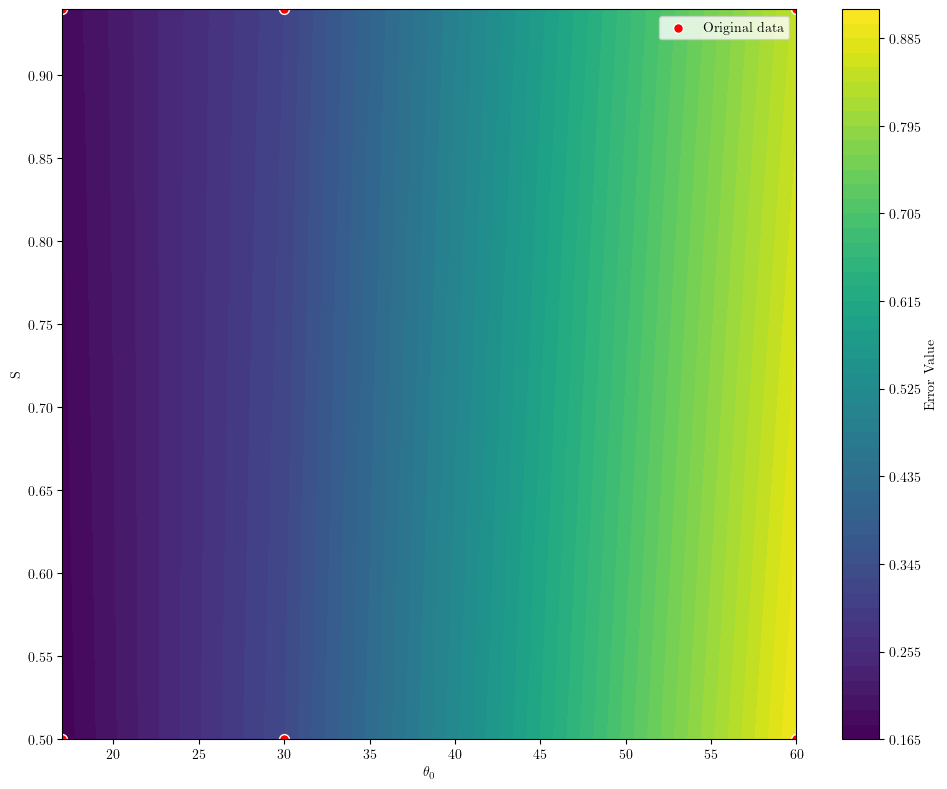

In [47]:
# Crear malla densa 100x100 para el mapa de color
s_dense = np.linspace(s_unique.min(), s_unique.max(), 100)
i_dense = np.linspace(i_unique.min(), i_unique.max(), 100)
S_dense, I_dense = np.meshgrid(s_dense, i_dense, indexing='ij')

# Crear array de puntos para evaluar (forma: (10000, 2))
points = np.column_stack((S_dense.ravel(), I_dense.ravel()))

# Evaluar el interpolador en todos los puntos
Z_map = interpolator(points)

# Reformar a la forma 100x100
Z_map = Z_map.reshape(100, 100)

print(f"Mapa de color creado: {Z_map.shape}")
print(f"Rango de valores interpolados: {Z_map.min():.4f} a {Z_map.max():.4f}")

# Visualizar el mapa de color
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
im = plt.contourf(I_dense, S_dense, Z_map, levels=50, cmap='viridis')
plt.colorbar(im, label='Error Value')

# Marcar puntos originales
plt.scatter(i_array, s_array, c='red', s=50, edgecolors='white', label='Original data')
plt.xlabel(r'$\theta_0$')
plt.ylabel('S')
plt.legend()
plt.tight_layout()
plt.savefig(rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes\ColorMap.png")
plt.show()